# Import Libraries

In [42]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tensorflow.keras.datasets import mnist

In [43]:
np.random.seed(42)

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_context("notebook", font_scale=1.1)

# Load Dataset

In [44]:
(X_train_raw, y_train), (X_test_raw, y_test) = mnist.load_data()

In [45]:
print(f"Raw Training data shape: {X_train_raw.shape}")
print(f"Raw Test data shape: {X_test_raw.shape}")

Raw Training data shape: (60000, 28, 28)
Raw Test data shape: (10000, 28, 28)


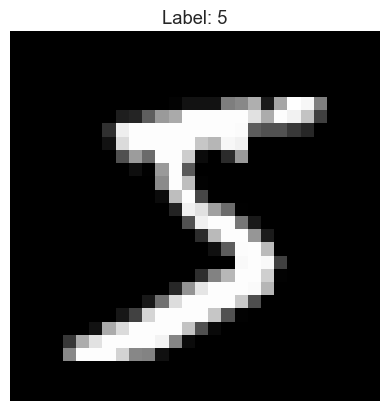

In [46]:
plt.imshow(X_train_raw[0], cmap='gray')
plt.title(f"Label: {y_train[0]}")
plt.axis('off')
plt.show()

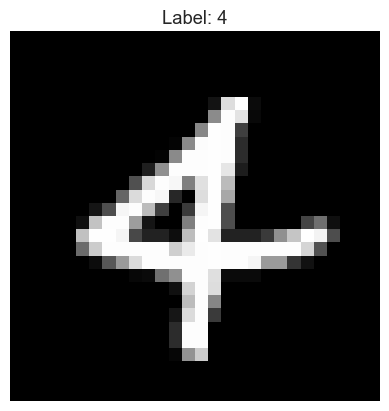

In [47]:
plt.imshow(X_train_raw[150], cmap='gray')
plt.title(f"Label: {y_train[150]}")
plt.axis('off')
plt.show()

### Flatten the 2D images (28x28) into 1D arrays (784) Scale (0.0 to 1.0)

In [48]:
X_train_flat = X_train_raw.reshape(X_train_raw.shape[0], -1).astype('float32') / 255.0
X_test_flat = X_test_raw.reshape(X_test_raw.shape[0], -1).astype('float32') / 255.0

In [49]:
print(f"Final Training Data Shape: {X_train_flat.shape}")
print(f"Final Test Data Shape: {X_test_flat.shape}")
print(f"Min pixel value: {X_train_flat.min()}, Max pixel value: {X_train_flat.max()}")

Final Training Data Shape: (60000, 784)
Final Test Data Shape: (10000, 784)
Min pixel value: 0.0, Max pixel value: 1.0


# Random Forest Baseline

In [57]:
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)

In [58]:
start_time = time.time()
rf_baseline.fit(X_train_flat, y_train)
train_time = time.time() - start_time
print(f"Training completed in {train_time:.2f} seconds.")

Training completed in 47.58 seconds.


In [52]:
inference_start = time.time()
y_pred_rf = rf_baseline.predict(X_test_flat)
inference_time = time.time() - inference_start

In [53]:
baseline_accuracy = accuracy_score(y_test, y_pred_rf)

In [54]:
print(f"Inference completed in {inference_time:.2f} seconds.")
print(f"Baseline Random Forest Accuracy: {baseline_accuracy * 100:.2f}%")

Inference completed in 0.35 seconds.
Baseline Random Forest Accuracy: 97.04%


In [55]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.98      0.96      0.97       892
           6       0.98      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.95      0.96       974
           9       0.96      0.95      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [67]:
cm = confusion_matrix(y_test, y_pred_rf)

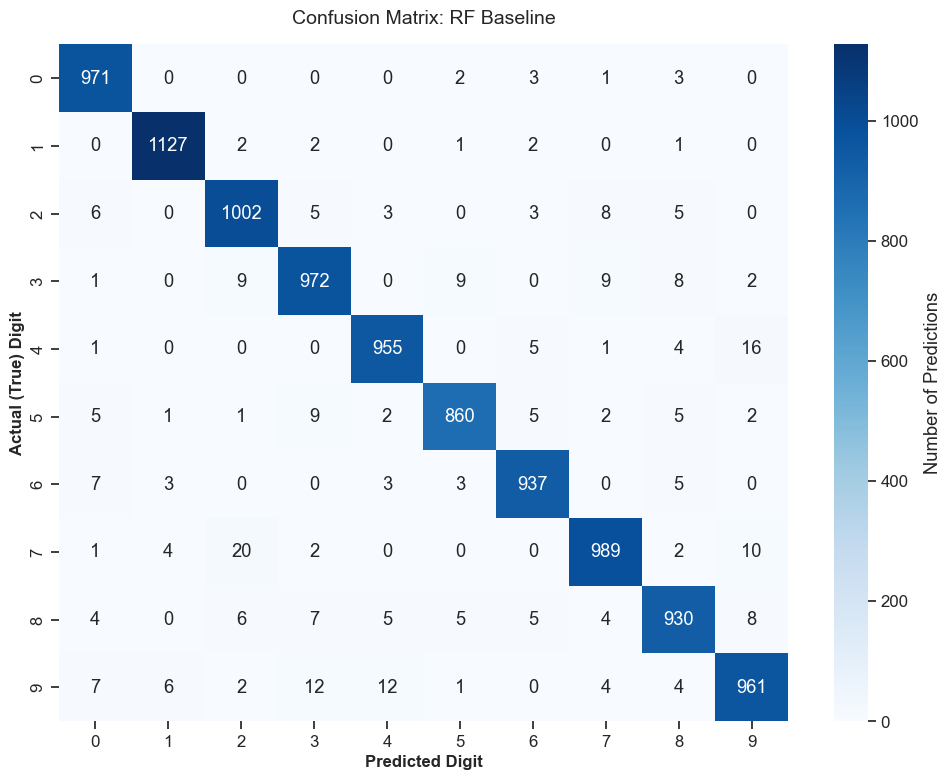

In [68]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Number of Predictions'})

plt.xlabel('Predicted Digit', fontsize=12, fontweight='bold')
plt.ylabel('Actual (True) Digit', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix: RF Baseline', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Random Forest Tuning

In [22]:
from sklearn.model_selection import RandomizedSearchCV

In [23]:
param_dist = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 20, 30, 40],
    'min_samples_split': [2, 5, 10]
}

In [24]:
rf_tune = RandomForestClassifier(random_state=42, n_jobs=-1)

In [25]:
search_start = time.time()

random_search = RandomizedSearchCV(
    estimator=rf_tune, 
    param_distributions=param_dist, 
    n_iter=5,
    cv=3,
    scoring='accuracy', 
    random_state=42, 
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_train_flat, y_train)

search_time = time.time() - search_start

Fitting 3 folds for each of 5 candidates, totalling 15 fits


In [26]:
print(f"Search completed in {search_time:.2f} seconds.")
print(f"Best Parameters: {random_search.best_params_}")

Search completed in 1063.29 seconds.
Best Parameters: {'n_estimators': 200, 'min_samples_split': 5, 'max_depth': 20}


In [27]:
best_rf = random_search.best_estimator_

In [34]:
inf_start = time.time()
best_rf_preds = best_rf.predict(X_test_flat)
inf_time = time.time() - inf_start

In [35]:
print(f"Optimized Inference Time: {inf_time:.2f} seconds.")
print(f"Optimized RF Accuracy: {accuracy_score(y_test, best_rf_preds) * 100:.2f}%")

Optimized Inference Time: 0.73 seconds.
Optimized RF Accuracy: 96.94%


In [36]:
print(classification_report(y_test, best_rf_preds))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       980
           1       0.99      0.99      0.99      1135
           2       0.96      0.97      0.97      1032
           3       0.96      0.96      0.96      1010
           4       0.97      0.97      0.97       982
           5       0.97      0.96      0.97       892
           6       0.97      0.98      0.98       958
           7       0.97      0.96      0.97      1028
           8       0.96      0.96      0.96       974
           9       0.95      0.95      0.95      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



In [76]:
cm = confusion_matrix(y_test, best_rf_preds)

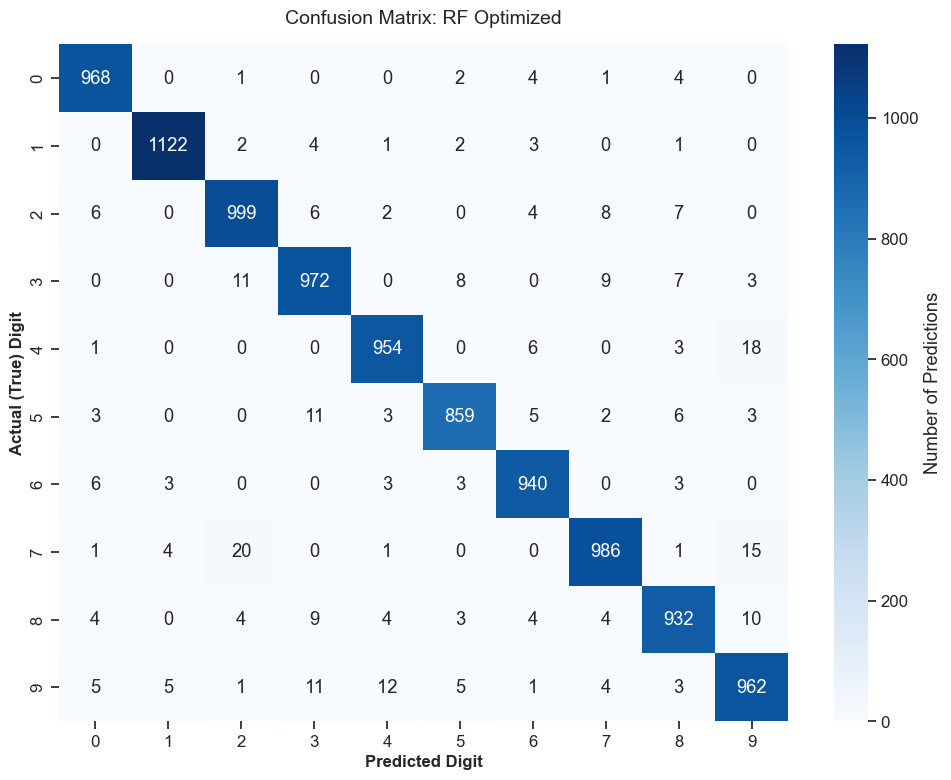

In [77]:
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=range(10), yticklabels=range(10),
            cbar_kws={'label': 'Number of Predictions'})

plt.xlabel('Predicted Digit', fontsize=12, fontweight='bold')
plt.ylabel('Actual (True) Digit', fontsize=12, fontweight='bold')
plt.title('Confusion Matrix: RF Optimized', fontsize=14, pad=15)
plt.tight_layout()
plt.show()

# Save the Model

In [71]:
import joblib
import os

In [72]:
model_dir = '../models'
os.makedirs(model_dir, exist_ok=True)

In [73]:
model_path = os.path.join(model_dir, 'optimized_rf_pipeline.joblib')

In [74]:
joblib.dump(random_search.best_estimator_, model_path)

['../models\\optimized_rf_pipeline.joblib']

In [75]:
print(f"Model successfully saved to: {model_path}")
print(f"File size: {os.path.getsize(model_path) / (1024 * 1024):.2f} MB")

Model successfully saved to: ../models\optimized_rf_pipeline.joblib
File size: 196.60 MB
